# Cosimita: time dependence and event files

Two pieces of bookkeeping, neither of which is physics, but both of which you
need before a simulation is any use as *data*:

- **time-dependent normalization** -- sources whose brightness changes during a
  run, so a transient or a duty cycle can be simulated at all;
- **an event file** -- one self-describing CSV holding every photon launched,
  its ground truth, and what the instrument made of it.

In [1]:
from gammaraytoys import ToyTracker2D
from gammaraytoys.coordinates import Cartesian2D
from gammaraytoys.sims import (PointSource, IsotropicSource, ExtendedSource,
                               NearPointSource, MonoenergeticSpectrum, Earth,
                               SpacecraftHistory, ZenithPointing, InertialSimulator,
                               SimpleTraditionalReconstructor,
                               ConstantScaling, TabulatedScaling, BurstScaling,
                               SinusoidalScaling,
                               write_event_csv, read_event_csv)
from histpy import Histogram, Axis
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
import tempfile, os

np.random.seed(0)

# Write the example files to a scratch directory rather than next to the
# notebook: re-running this notebook should not leave generated data in
# the repository.
scratch = tempfile.mkdtemp(prefix = 'cosimita_')

comptelito = ToyTracker2D(material = 'Ge',
                          layer_length = 10*u.m,
                          layer_positions = np.append(300, np.arange(0,10,1))*u.cm,
                          layer_thickness = 1*u.cm,
                          energy_resolution = 0.03,
                          energy_threshold = 20*u.keV)

earth = Earth(radius = 6371*u.km)
reco = SimpleTraditionalReconstructor()

history = SpacecraftHistory.from_elliptical_orbit(semi_major_axis = earth.radius + 400*u.km,
                                                  duration = 6000*u.s, time_step = 100*u.s,
                                                  earth = earth,
                                                  observation_strategy = ZenithPointing())

print(f"{len(list(history))} intervals over {history.total_livetime:.0f}")

60 intervals over 6000 s


## 1. Scaling: a unitless multiplier on the source's normalization

Every source now takes an optional `scaling`. It multiplies the flux or rate
when the simulator forms its Poisson mean, and it is evaluated **once per
interval, at the interval's midpoint** -- not per photon. Defaults to
`ConstantScaling(1.0)`, so a source built without one behaves exactly as before.

Four kinds:

- `ConstantScaling(s)` -- a fixed multiplier.
- `TabulatedScaling(time, scale)` -- **piecewise constant**, from a table or a
  two-column CSV via `.open()`.
- `BurstScaling(start, duration, amplitude)` -- `amplitude` inside the window,
  zero outside it.
- `SinusoidalScaling(mean, amplitude, period, reference_time)` --
  `mean + amplitude*sin(2*pi*(t - reference_time)/period)`.

All four are built from plain numbers, which is deliberate: a scaling is the
one thing a configuration file could have expressed as a formula, and fixed
shapes with named parameters are the reason such a file never has to contain
anything resembling code.

The piecewise-constant rule is worth stating precisely, because the obvious
implementations disagree at exactly the interesting points. The value at `t` is
the scale from **the last row whose time is `<= t`**; before the first row you
get the first row's value, after the last you get the last row's.

In [2]:
times = [0, 1500, 3000, 4500]*u.s
scales = [1.0, 3.0, 0.5, 2.0]
tabulated = TabulatedScaling(times, scales)

print("the three properties that follow from 'last row with time <= t':\n")
print(f"{'t [s]':>9} {'scale':>7}   what it shows")
for t, note in [(-500, 'before the first row -> clamps, does not extrapolate'),
                (1499.999, 'still the old value'),
                (1500.0, 'ON the breakpoint -> the NEW value, not the old'),
                (1500.001, 'and flat from there'),
                (3000.0, 'ON the next breakpoint'),
                (9999.0, 'after the last row -> clamps again')]:
    print(f"{t:9.3f} {tabulated(t*u.s):7.2f}   {note}")

the three properties that follow from 'last row with time <= t':

    t [s]   scale   what it shows
 -500.000    1.00   before the first row -> clamps, does not extrapolate
 1499.999    1.00   still the old value
 1500.000    3.00   ON the breakpoint -> the NEW value, not the old
 1500.001    3.00   and flat from there
 3000.000    0.50   ON the next breakpoint
 9999.000    2.00   after the last row -> clamps again


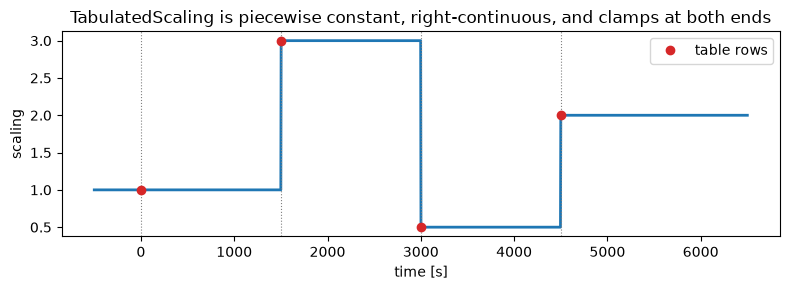

In [3]:
t_grid = np.linspace(-500, 6500, 2000)*u.s
values = np.array([tabulated(t) for t in t_grid])

fig, ax = plt.subplots(figsize = (8, 3))
ax.plot(t_grid.to_value(u.s), values, color = 'tab:blue', lw = 2)
ax.plot(times.to_value(u.s), scales, 'o', color = 'tab:red', zorder = 3,
        label = 'table rows')
for t in times.to_value(u.s):
    ax.axvline(t, color = 'gray', ls = ':', lw = .8)
ax.set_xlabel('time [s]'); ax.set_ylabel('scaling')
ax.set_title('TabulatedScaling is piecewise constant, right-continuous, and clamps at both ends')
ax.legend()
fig.tight_layout()

The filled dots sit at the **left** end of each step, not the right: a
breakpoint belongs to the row at it. Outside the table the curve is flat rather
than continuing the last trend -- extrapolating a scaling nobody measured would
be inventing data.

## 2. What scaling does to a run

The simplest check that it is wired in at all: double the scaling, get twice
the photons.

In [4]:
def launched_counts(scaling, seed = 1):
    """Number of photons launched by one source over the whole history."""
    source = PointSource(sky_angle = 40*u.deg,
                         spectrum = MonoenergeticSpectrum(1*u.MeV),
                         flux = 3e-4/u.cm/u.s,
                         scaling = scaling)
    simulator = InertialSimulator(detector = comptelito, sources = source,
                                  reconstructor = reco, spacecraft_history = history,
                                  earth = earth)
    np.random.seed(seed)
    return len(list(simulator.run_events(progress = False)))

n1 = launched_counts(ConstantScaling(1.0))
n2 = launched_counts(ConstantScaling(2.0))
print(f"  scaling = 1 -> {n1} photons")
print(f"  scaling = 2 -> {n2} photons")
print(f"  ratio {n2/n1:.3f}, expected 2; Poisson sigma on the ratio is "
      f"about {np.sqrt(1/n1 + 1/n2)*2:.3f}")

  scaling = 1 -> 1161 photons
  scaling = 2 -> 2411 photons
  ratio 2.077, expected 2; Poisson sigma on the ratio is about 0.071


Something more interesting than a constant: a source that switches on for part
of the orbit. This is how you would simulate a duty cycle, an occultation the
`Earth` model does not cover, or a transient.

  947 photons total, 0 of them outside the burst window
  (zero outside is expected: the scaling there is exactly 0)


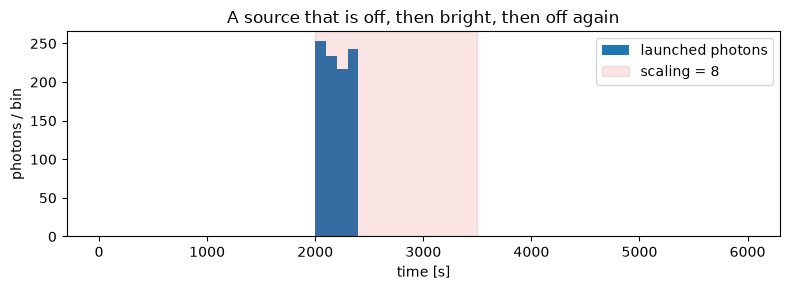

In [5]:
# Off, then bright, then off again -- a burst covering part of the run.
burst = BurstScaling(start = 2000*u.s, duration = 1500*u.s, amplitude = 8.0)

# The same shape as TabulatedScaling([0, 2000, 3500]*u.s, [0.0, 8.0, 0.0]):
# the burst window is half-open, `start <= t < start + duration`, exactly so
# that it agrees with the table's rule that a breakpoint belongs to the row at
# it. Two scalings that disagreed about their edges would be a trap.

source = PointSource(sky_angle = 40*u.deg,
                     spectrum = MonoenergeticSpectrum(1*u.MeV),
                     flux = 3e-4/u.cm/u.s,
                     scaling = burst)
simulator = InertialSimulator(detector = comptelito, sources = source,
                              reconstructor = reco, spacecraft_history = history,
                              earth = earth)

np.random.seed(3)
events = list(simulator.run_events(progress = False))
times = np.array([t.to_value(u.s) for t, _, _, _ in events])

fig, ax = plt.subplots(figsize = (8, 3))
ax.hist(times, bins = 60, range = (0, 6000), color = 'tab:blue', label = 'launched photons')
ax.axvspan(2000, 3500, color = 'tab:red', alpha = .12, label = 'scaling = 8')
ax.set_xlabel('time [s]'); ax.set_ylabel('photons / bin')
ax.set_title('A source that is off, then bright, then off again')
ax.legend()
fig.tight_layout()

outside = np.sum((times < 2000) | (times >= 3500))
print(f"  {len(times)} photons total, {outside} of them outside the burst window")
print(f"  (zero outside is expected: the scaling there is exactly 0)")

Note the edges land on **interval** boundaries, not exactly on 2000 s and
3500 s. The scaling is evaluated once per interval at its midpoint, so an
interval is either wholly in the burst or wholly out of it. That is a
deliberate consequence of the `.ori` interval semantics, not an approximation
error -- the spacecraft history is the time resolution of the whole simulation.

`SinusoidalScaling` covers the other common shape, for anything smoother:

  at t = 500 s (a quarter period): 1.5


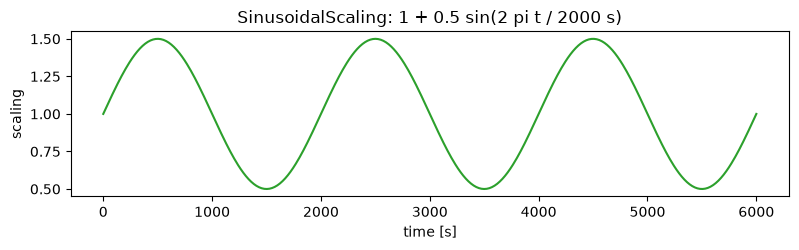

In [6]:
modulated = SinusoidalScaling(mean = 1.0, amplitude = 0.5, period = 2000*u.s)

t_grid = np.linspace(0, 6000, 500)*u.s
fig, ax = plt.subplots(figsize = (8, 2.6))
ax.plot(t_grid.to_value(u.s), [modulated(t) for t in t_grid], color = 'tab:green')
ax.set_xlabel('time [s]'); ax.set_ylabel('scaling')
ax.set_title('SinusoidalScaling: 1 + 0.5 sin(2 pi t / 2000 s)')
fig.tight_layout()

# A quarter period in is a full swing up, so this must read exactly 1.5.
print(f"  at t = 500 s (a quarter period): {modulated(500*u.s)}")


## 3. The event file

`write_event_csv` dumps every photon **actually launched** -- its ground truth
and the instrument's reconstruction -- into one CSV with a `#`-prefixed YAML
metadata header, so a file carries its own provenance and nothing can drift
apart from its data.

Occulted photons never appear: they were never launched, and the livetime in
the metadata already accounts for them.

In [7]:
crab = PointSource(sky_angle = 40*u.deg, spectrum = MonoenergeticSpectrum(1*u.MeV),
                   flux = 3e-4/u.cm/u.s)
diffuse = IsotropicSource(spectrum = MonoenergeticSpectrum(0.5*u.MeV),
                          flux = 2e-4/u.cm/u.s)
internal = NearPointSource(position = comptelito.surrounding_circle_center,
                           spectrum = MonoenergeticSpectrum(0.3*u.MeV), rate = 0.05/u.s)

simulator = InertialSimulator(detector = comptelito, sources = [crab, diffuse, internal],
                              reconstructor = reco, spacecraft_history = history,
                              earth = earth)

np.random.seed(5)
events = list(simulator.run_events(progress = False))

# `spacecraft_history` lets the writer recover each photon's own inertial sky
# angle as `lambda = A - Nu`. Without it that column can only be filled for a
# source whose sky angle is a fixed constant.
event_file = os.path.join(scratch, 'events.csv')
write_event_csv(event_file, events,
                source_names = {crab: 'crab', diffuse: 'diffuse', internal: 'internal'},
                ori_file = 'cosimita_400km.ori',
                total_livetime = history.total_livetime,
                spacecraft_history = history)

print(open(event_file).read().split(chr(10) + 'event_id')[0])
print('event_id,...  (' + str(len(events)) + ' rows follow)')

# gammaraytoys_version: 0.0.1
# ori_file: cosimita_400km.ori
# total_livetime_s: 6000.0
# nsim: {crab: 1234, diffuse: 747, internal: 295}
# triggered_only: false
event_id,...  (2276 rows follow)


In [8]:
metadata, data = read_event_csv(event_file)

print("metadata read back:")
for key, value in metadata.items():
    print(f"  {key:20s} {value}")
print(f"\ncolumns: {list(data.columns)}")
print(f"\nrows: {len(data)}   triggered: {int(data.triggered.sum())}")
data.head(4)

metadata read back:
  gammaraytoys_version 0.0.1
  ori_file             cosimita_400km.ori
  total_livetime_s     6000.0
  nsim                 {'crab': 1234, 'diffuse': 747, 'internal': 295}
  triggered_only       False

columns: ['event_id', 'time_s', 'source', 'true_x_cm', 'true_y_cm', 'true_direction_deg', 'true_sky_angle_deg', 'true_offaxis_angle_deg', 'true_energy_MeV', 'true_chirality', 'triggered', 'reco_energy_MeV', 'reco_phi_deg', 'reco_psi_deg']

rows: 2276   triggered: 125


,event_id,time_s,source,true_x_cm,true_y_cm,true_direction_deg,true_sky_angle_deg,true_offaxis_angle_deg,true_energy_MeV,true_chirality,triggered,reco_energy_MeV,reco_phi_deg,reco_psi_deg
0,0,76.590786,crab,-350.275209,537.526812,310.0,40.0,-40.0,1.0,-1,False,NaN,NaN,NaN
1,1,47.740172,crab,-483.435656,425.791930,310.0,40.0,-40.0,1.0,-1,False,NaN,NaN,NaN
2,2,52.671757,crab,-464.184126,441.945882,310.0,40.0,-40.0,1.0,1,True,0.703572,17.758485,-27.499139
3,3,70.622076,crab,-684.281121,257.262575,310.0,40.0,-40.0,1.0,-1,False,NaN,NaN,NaN


Two conventions in that table worth knowing:

- **`true_sky_angle_deg` is empty for near-field sources.** They sit at a fixed
  detector-frame position and have no inertial sky angle at all -- the column is
  not missing data, it is a question that does not apply.
- **The `reco_*` columns are empty when `triggered` is false.** A photon that
  did not trigger has no reconstruction, so there is nothing to record.

In [9]:
for name in ['crab', 'diffuse', 'internal']:
    rows = data[data.source == name]
    known = rows.true_sky_angle_deg.notna().sum()
    line = f"  {name:9s}: {len(rows):4d} rows, true_sky_angle_deg set on {known:4d} of them"
    if known:
        line += f", spread {rows.true_sky_angle_deg.std():.2e} deg"
    print(line)

untriggered = data[~data.triggered]
print(f"\n  {len(untriggered)} untriggered rows, reco_energy_MeV all empty: "
      f"{untriggered.reco_energy_MeV.isna().all()}")

  crab     : 1234 rows, true_sky_angle_deg set on 1234 of them, spread 1.17e-14 deg
  diffuse  :  747 rows, true_sky_angle_deg set on  747 of them, spread 1.00e+02 deg
  internal :  295 rows, true_sky_angle_deg set on    0 of them

  2151 untriggered rows, reco_energy_MeV all empty: True


Those two spreads are the point of the column, and they differ by fourteen
orders of magnitude.

`crab` is a fixed point source, so every one of its photons really does come
from the same direction: its spread is `~1e-14 deg`, which is not zero only
because `lambda = A - Nu` is computed in floating point from a changing
attitude. Read it as zero. `diffuse` is isotropic, so its photons genuinely
arrive from all over the sky and its spread of ~100 deg is physical.

That contrast is why the column is filled per photon rather than per source.
Writing `crab`'s constant 40 deg would have looked identical here -- and would
have been wrong for `diffuse` by 100 degrees, silently. A column named `true_`
has to mean *this photon*, not *this source*, even when the two coincide.

`triggered_only = True` writes only the triggers, for when the untriggered
photons are not worth the disk:

In [10]:
triggered_file = os.path.join(scratch, 'events_triggered.csv')
write_event_csv(triggered_file, events, triggered_only = True,
                source_names = {crab: 'crab', diffuse: 'diffuse', internal: 'internal'},
                total_livetime = history.total_livetime,
                spacecraft_history = history)

meta_trig, data_trig = read_event_csv(triggered_file)

print(f"  full file      : {len(data)} rows, {int(data.triggered.sum())} triggered")
print(f"  triggered only : {len(data_trig)} rows")
print(f"  same events    : {set(data_trig.event_id) == set(data[data.triggered].event_id)}")
print(f"\n  nsim in both files is the launched count, unchanged by the filter:")
print(f"    full      {metadata['nsim']}")
print(f"    triggered {meta_trig['nsim']}")

  full file      : 2276 rows, 125 triggered
  triggered only : 125 rows
  same events    : True

  nsim in both files is the launched count, unchanged by the filter:
    full      {'crab': 1234, 'diffuse': 747, 'internal': 295}
    triggered {'crab': 1234, 'diffuse': 747, 'internal': 295}


`event_id` is assigned before the filter, so an id identifies the same photon in
both files -- the triggered-only file has gaps rather than a dense `0..n-1`
range. And `nsim` counts what was *launched* either way, because that is what
you need to normalize a rate; if the filter changed it, every flux computed from
a triggered-only file would be wrong.

## 4. The data, from the file

Everything the earlier notebooks plotted from live objects can be plotted from
the file instead -- which is the point of having one.

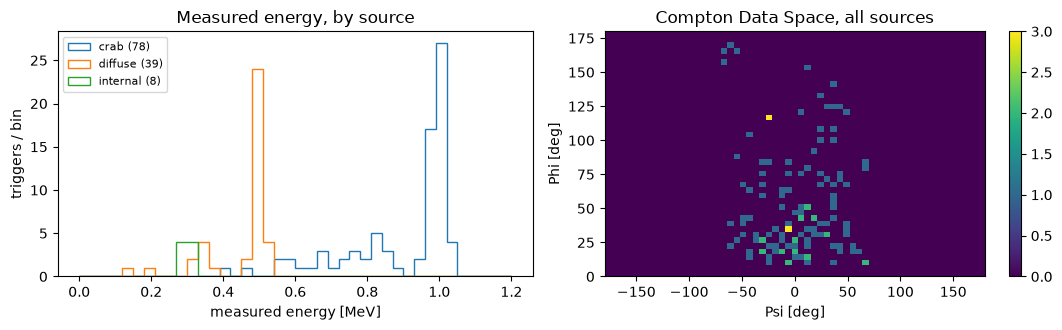

In [11]:
triggered = data[data.triggered]

phi_axis = Axis(np.linspace(0, 180, 45)*u.deg, label = 'Phi')
psi_axis = Axis(np.linspace(-180, 180, 60)*u.deg, label = 'Psi')

fig, ax = plt.subplots(figsize = (11, 3.4), ncols = 2)

for name, colour in [('crab', 'tab:blue'), ('diffuse', 'tab:orange'), ('internal', 'tab:green')]:
    rows = triggered[triggered.source == name]
    ax[0].hist(rows.reco_energy_MeV, bins = 40, range = (0, 1.2), histtype = 'step',
               color = colour, label = f'{name} ({len(rows)})')
ax[0].set_xlabel('measured energy [MeV]'); ax[0].set_ylabel('triggers / bin')
ax[0].set_title('Measured energy, by source')
ax[0].legend(fontsize = 8)

h = Histogram([psi_axis, phi_axis])
h.fill(triggered.reco_psi_deg.to_numpy()*u.deg,
       triggered.reco_phi_deg.to_numpy()*u.deg, warn_overflow = False)
h.plot(ax[1])
ax[1].set_title('Compton Data Space, all sources')

fig.tight_layout()

Three sources, three line energies, one file. The `source` column is ground
truth that no real instrument would have -- which is exactly what makes a
simulated event file useful for testing an analysis: you can check what the
analysis recovers against what actually happened.